# Grupo 9 - Trabajo Práctico - Computer Vision 2025 - DUIA

Integrantes del grupo:

* Ariel Machini
* Juan Francisco Herrero
* Martino Ferrero

**Objetivo:** Llevar a cabo una red de clasificación para el dataset `CIFAR-10` (clases airplane, automobile, bird, cat, deer, dog, frog, horse, ship y truck), tomando 50000 imágenes de entrenamiento, 10000 de validación, y el dataset `CIFAR-10.1` para testing.

**Link a presentación:** https://docs.google.com/presentation/d/1gGa-4K8SyUm0slVgYUjG0mW740-lsN8zBvNkdvrubzY/edit?slide=id.g36cfb1982a3_0_251#slide=id.g36cfb1982a3_0_251

**Link a tablas con configuraciones de hiperparámetros, arquitecturas y resultados de todos los experimentos:** https://docs.google.com/spreadsheets/d/1Il3_cRBvcbeHKm_CFO7u2kUYGI4p_EpyuxHrUFeEYjM/edit?gid=0#gid=0

**NOTA: Al haber hecho tantos experimentos, por cuestiones de tiempo en la presentación solo se incluyen 12 modelos, los cuales son los 8 primeros para forzar y luego mitigar el overfitting, y algunos de los siguientes como el 10, 10.2, 20 y 22 (siendo el 22 el mejor experimento de todos), ya que presentan características, arquitecturas y resultados interesantes. Pero si se quieren ver otros modelos que presentan otras variantes de prueba (por ejemplo el uso de AdamW como optimizador, variantes de arquitectura, etc), se puede ver dichas tablas adjuntadas más en detalle.**

## 1. Importación de paquetes
Instalamos `torchcam` con `pip` para generar mapas de calor de GradCAM al final.

In [ ]:
!pip install torchcam

In [ ]:
import copy
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import seaborn as sns
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import warnings
from google.colab import drive
from IPython.display import display
from os import makedirs
from os import path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode, v2 as transformations
from torchvision.transforms.functional import to_pil_image

## 2. Configuración del ambiente y descarga de datos
En esta sección del notebook definimos semillas para intentar garantizar reproducibilidad entre ejecuciones.

In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
gdrive_dir = '/content/gdrive/'
base_dir = gdrive_dir + 'My Drive/Colab Notebooks/DUIA/2021/Computer Vision/'

drive.mount(gdrive_dir)

datasets_folder = base_dir + 'Grupo 9'
makedirs(datasets_folder, exist_ok = True)

# Descarga del conjunto CIFAR 10.1, para testing:
new_datasets_folder = base_dir
makedirs(new_datasets_folder, exist_ok = True)

!rm /content/gdrive/My\ Drive/Colab\ Notebooks/DUIA/2021/Computer\ Vision/cifar10.1_v4_data.npy*
!rm /content/gdrive/My\ Drive/Colab\ Notebooks/DUIA/2021/Computer\ Vision/cifar10.1_v4_labels.npy*

!wget --no-check-certificate -P /content/gdrive/My\ Drive/Colab\ Notebooks/DUIA/2021/Computer\ Vision/ https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v4_data.npy
!wget --no-check-certificate -P /content/gdrive/My\ Drive/Colab\ Notebooks/DUIA/2021/Computer\ Vision/ https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v4_labels.npy

!ls /content/gdrive/My\ Drive/Colab\ Notebooks/DUIA/2021/Computer\ Vision/

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
--2025-10-27 20:20:02--  https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v4_data.npy
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/modestyachts/CIFAR-10.1/master/datasets/cifar10.1_v4_data.npy [following]
--2025-10-27 20:20:02--  https://raw.githubusercontent.com/modestyachts/CIFAR-10.1/master/datasets/cifar10.1_v4_data.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6208640 (5.9M) [application/octet-stream]
Saving to: ‘/content/gdriv

In [ ]:
seed = 42

np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## 3. Acceso a los datos
Usando el paquete `datasets.CIFAR10` de PyTorch, definimos los conjuntos de prueba y validación. En esta sección, también calculamos la media y la desviación estándar para estandarizar los datos de entrenamiento (ya que observamos mejores resultados aplicando esta transformación), y definimos el resto de las transformaciones.

Los valores de media para los canales rojo, verde y azul son de 0.4914, 0.4822, 0.4465 respectivamente. Por su lado, los de desviación estándar son de 0.2470, 0.2435, 0.2616. Dichos valores coinciden con los que en Internet se conocen para el dataset, lo que confirma que están correctamente calculados.

In [ ]:
cifar10_training = datasets.CIFAR10(datasets_folder, train = True, download = True, transform = transformations.ToTensor())

# Calculamos la media y la desviación estándar:
imgs = [item[0] for item in cifar10_training]
imgs = torch.stack(imgs, dim=0).numpy()

mean_r = imgs[:,0,:,:].mean()
mean_g = imgs[:,1,:,:].mean()
mean_b = imgs[:,2,:,:].mean()

std_r = imgs[:,0,:,:].std()
std_g = imgs[:,1,:,:].std()
std_b = imgs[:,2,:,:].std()

mean = (mean_r, mean_g, mean_b)
std  = (std_r, std_g, std_b)

print(f"Media: {mean_r:.4f}, {mean_g:.4f}, {mean_b:.4f}")
print(f"Desviación estándar: {std_r:.4f}, {std_g:.4f}, {std_b:.4f}")

Media: 0.4914, 0.4822, 0.4465
Desviación estándar: 0.2470, 0.2435, 0.2616


In [ ]:
classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

def get_one_per_class(indices, labels, n_classes = 10):
    selected_indices = []
    selected_labels = []
    used_classes = set()

    for idx in indices:
        cls = labels[idx]

        if cls not in used_classes:
            selected_indices.append(idx)
            selected_labels.append(cls)
            used_classes.add(cls)

        if len(used_classes) == n_classes:
            break

    return selected_indices, selected_labels

all_labels_training = [label for _, label in cifar10_training]
selected_indices, selected_labels = get_one_per_class(np.arange(len(cifar10_training)), all_labels_training, n_classes = len(classes))
original_imgs = [cifar10_training[idx][0] for idx in selected_indices]

En la siguiente celda definimos la lista de transformaciones para los conjuntos de entrenamiento y validación/testing. A continuación incluimos el razonamiento tras la selección de cada una de estas:
* **RandomCrop:** Esta fue la última transformación que seleccionamos para el conjunto de entrenamiento. Contrario a lo que esperábamos, esta transformación generó un impacto positivo en el entrenamiento.
* **RandomHorizontalFlip:** Rota horizontalmente la imagen con una probabilidad del 50 % (valor por defecto).
* **RandomRotation:** Rota la imagen aleatoriamente entre -30 y 30 grados. Decidimos limitar el ángulo de rotación entre estos valores para no generar imágenes sin sentido (por ejemplo, autos a 90 grados o barcos volteados).
* **ColorJitter:** Para esta transformación en particular probamos distintos rangos de valores. Al igual que con `RandomRotation`, buscamos elegir números que tuviesen sentido (de acuerdo a nuestra subjetividad, por supuesto). En el caso de `brightness`, elegimos valores que no se alejaran mucho de 1 (±0.2) ya que consideramos que alterar mucho el brillo de la imagen resulta en colores o muy apagados, o muy lavados. Por otro lado, para `contrast` y `saturation` optamos por rangos que intensificaran estas características, ya que creemos que ayudan a resaltar los bordes de los elementos de interés dentro de las imágenes.
* **ToTensor:** Para convertir las imágenes a tensores de PyTorch con forma (C,H,W), o sea primero canales, luego altura y finalmente ancho. También realiza un escalado al rango de flotantes entre 0.0 y 1.0.
* **Normalize:** Estandarización aplicada sobre el conjunto de entrenamiento, usando la media y la desviación estándar (estos valores fueron calculados más arriba). Probamos el modelo tanto **con** estandarización como **sin** estandarización, y obtuvimos mejores resultados durante el entrenamiento **aplicando** esta transformación.

In [ ]:
list_of_training_transformations = [
    transformations.RandomCrop(32, padding = 4),
    transformations.RandomHorizontalFlip(), # Probabilidad por defecto: 0.5.
    transformations.RandomRotation(degrees = (-30, 30), interpolation = InterpolationMode.BILINEAR),
    transformations.ColorJitter(brightness = (0.8, 1.2), contrast = (0.9, 1.4), saturation = (1, 1.4)),
    transformations.ToTensor(),
    transformations.Normalize(mean, std)
    ]

list_of_test_transformations = [
    transformations.ToTensor(),
    transformations.Normalize(mean, std)
    ]

training_transformations = transformations.Compose(list_of_training_transformations)
test_transformations = transformations.Compose(list_of_test_transformations)

In [ ]:
cifar10_training = datasets.CIFAR10(datasets_folder, train = True, download = True, transform = training_transformations)
cifar10_validation = datasets.CIFAR10(datasets_folder, train = False, download = True, transform = test_transformations)

Visualizamos algunas imágnes originales con transformaciones por cada una pero desnormalizadas (simplemente para entenderlas mejor de forma visual ya que con la normalización no se verían bien los colores reales).

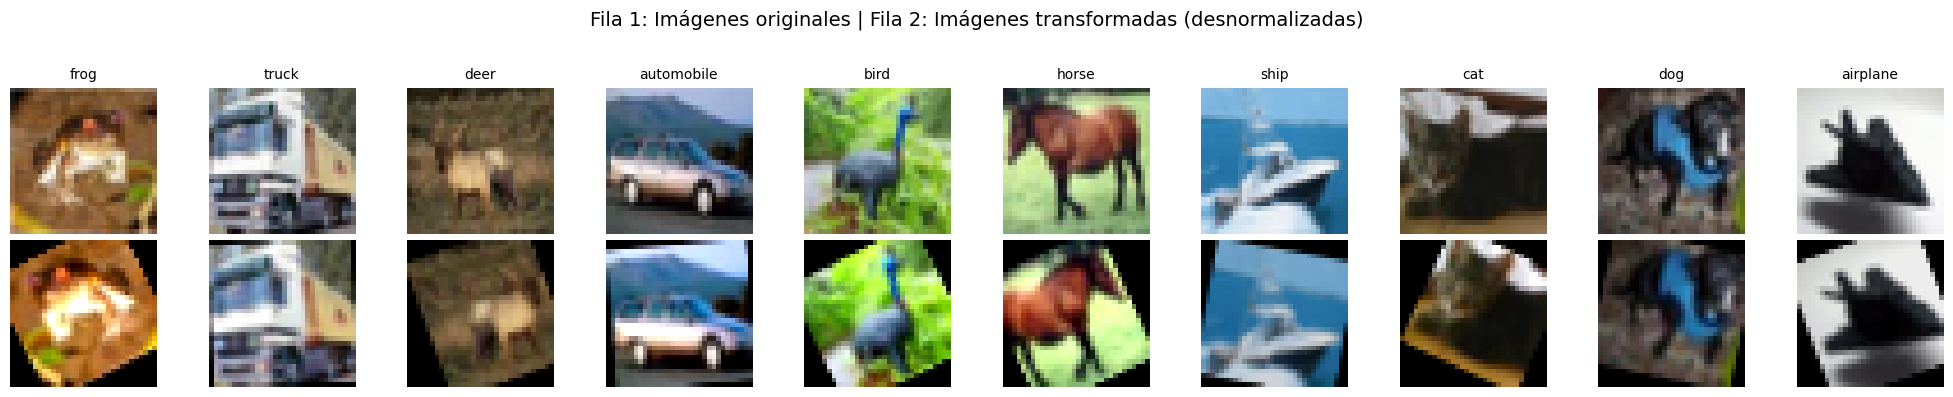

In [ ]:
transformed_imgs = [training_transformations(img) for img in original_imgs]
mean_tensor = torch.tensor(mean).view(3,1,1)
std_tensor = torch.tensor(std).view(3,1,1)

fig, axes = plt.subplots(2, 10, figsize = (20, 4))

for col in range(10):
    axes[0, col].imshow(original_imgs[col].permute(1, 2, 0))
    axes[0, col].set_title(f"{classes[selected_labels[col]]}", fontsize = 10)
    axes[0, col].axis('off')

    transformed_img = transformed_imgs[col] * std_tensor + mean_tensor
    transformed_img = transformed_img.permute(1, 2, 0)
    transformed_img = torch.clamp(transformed_img, 0, 1)

    axes[1, col].imshow(transformed_img)
    axes[1, col].axis('off')

plt.suptitle("Fila 1: Imágenes originales | Fila 2: Imágenes transformadas (desnormalizadas)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4. Implementación de la arquitectura de la red neuronal convolucional

Tras probar una gran cantidad de arquitecturas a lo largo de varios experimentos, en el mejor de todos llegamos a la que se presenta a continuación. Algunos de los componentes fundamentales de la misma son:

- ***Convoluciones 2d con kernel de 3x3*** : Para la extracción de características mediante la aplicación de un conjunto de filtros o kernels de 3x3. Algunas de ellas cuentan con stride de 2 para reducir el tamaño espacial del mapa de características a la mitad, mientras que otras lo mantienen en 1, lo cual junto con el padding de 1 permite mantener el mismo tamaño en esos casos. Al tener muchas capas convolucionales apiladas, la red aprende patrones o representaciones cada vez más abstractas o globales (al principio son patrones simples y se van combinando en patrones más complejos a medida que va avanzando en capas más profundas).

- ***Batch normalization 2d*** : Para la normalización de las activaciones del mapa de características resultante de cada convolución, lo cual permite estabilizar la propagación del gradiente y además acelera la convergencia (esto anula la necesidad del bias, por lo que se desactiva el aprendizaje del mismo en las capas convolucionales, ya que no tiene influencia y ajustarlo solo implicaría más costo computacional).

- ***Función de activación GELU*** : Para poder introducir no linealidad de una manera más suave que con la clásica ReLU. Si bien es un poco más costosa computacionalmente, es menos tendiente a algunos problemas como el de las neuronas muertas, ya que GELU en lugar de cortar de manera abrupta los valores negativos los atenua de manera suave, por lo que un valor negativo genera una salida pequeña y no 0.

- ***Bloques y conexiones residuales*** : Una de las principales ventajas de la arquitectura actual respecto a las de los experimentos previos. El uso de estos permite reducir o mitigar el fenómeno del desvanecimiento del gradiente (que ocurre cuando la profundidad de una red genera que durante la propagación del gradiente, este se vuelva demasiado pequeño en las primeras capas, que sus parámetros no cambien significativamente y que por consiguiente la red no aprenda bien). Para ello, se usan conexiones de salto que suman la entrada de un bloque residual a su salida (de esta manera el modelo aprende una función residual). Así, la propagación del gradiente fluye mucho mejor incluso hasta las primeras capas. En este caso los bloques residuales se componen de:
    
    - **Sub bloque 1** : Convolución 2d de 3x3 con padding de 1, stride igual al que se especifica para el bloque residual (puede ser de 1 o 2 para reducir el tamaño espacial a la mitad del mapa de características), y filtros de entrada y salida iguales a los especificados para el bloque residual en sí, seguido de batch normalization y una activación GELU.
    
    - **Sub bloque 2** : Convolución 2d de 3x3 con padding y stride de 1 (nunca se reduce el tamaño espacial en la segunda convolución del bloque), filtros de entrada y salida iguales al número de filtros de salida del bloque (nunca se incrementa el número de filtros de salida en la segunda convolución del bloque), seguido de batch normalization, la suma con la identidad, y finalmente una activación GELU. Cabe aclarar que la identidad resulta de aplicar un shortcut a la entrada del bloque residual. Ese shortcut es una operación secuencial vacía cuando el bloque residual no tiene stride o no cambia el número de filtros de la entrada (lo cual corresponde al segundo bloque residual en todas las capas residuales). En cambio, si el stride es de 2 o el número de filtros de salida es mayor que el de la entrada (lo cual pasa en el primer bloque residual en las capas residuales), el shortcut corresponde a una convolución 2d en la que se ajusta el número de filtros de acuerdo a los de salida especificados para el bloque, y se aplica stride, y posteriormente se le hace un batch normalization. El objetivo es que la entrada que se suma a la salida sea matemáticamente equivalente (porque en esos casos el mapa de características que entra a la primera convolución no tiene iguales dimensiones que el que sale de la segunda convolución).

- ***Capas fully connected o densas*** : Para llevar a cabo la clasificación final en las 10 clases correspondientes, usando la información espacial extraida a partir de las capas convolucionales anteriores. Se usan capas lineales con activación GELU y dropout para apagar aleatoriamente algunas neuronas durante el forward pass (solo influye en el entrenamiento) y así reducir el efecto del fenómeno de overfitting. Cada neurona de estas capas se conecta con todas las entradas, capturando relaciones globales entre las características aprendidas.

Teniendo en cuenta estos aspectos, la arquitectura está dada por la siguiente estructura:

- ***Capa 1*** : Convolución 2d (3 filtros de entrada, 64 de salida), batch normalization sobre la salida y función de activación GELU. Usa stride de 1, por lo que no se reduce la resolución espacial original, que es de 32x32.

- ***Capa 2*** : 2 bloques residuales, el primero de ellos con 64 filtros de entrada y 128 de salida sumado a un stride de 2 (se reduce a la mitad la resolución espacial, o sea 16x16), y el segundo con 128 filtros de entrada y salida y stride de 1 (no se reduce la resolución espacial).

- ***Capa 3*** : 2 bloques residuales, el primero de ellos con 128 filtros de entrada y 256 de salida sumado a un stride de 2 (se reduce a la mitad la resolución espacial, o sea 8x8), y el segundo con 256 filtros de entrada y salida y stride de 1 (no se reduce la resolución espacial).

- ***Capa 4*** : 2 bloques residuales, el primero de ellos con 256 filtros de entrada y 512 de salida sumado a un stride de 2 (se reduce a la mitad la resolución espacial, o sea 4x4), y el segundo con 512 filtros de entrada y salida y stride de 1 (no se reduce la resolución espacial).

- ***Global Average Pooling*** : Calcula el promedio de todos los valores en cada uno de los 512 filtros o mapas de salida de la capa 4. Por lo tanto, en ese momento pasa de haber 512x4x4 activaciones a 512x1x1 (512). De esa forma, resume qué tanta fuerza tiene cada característica (representada por cada mapa en sí) en la imagen, y al bajar tanto el número de activaciones resulta mucho menos costoso computacionalmente (ya que deriva en muchos menos parámetros en las capas densas) y menos tendiente al overfitting. Finalmente, los 512 valores componen el vector que es la entrada de las capas densas del clasificador (al inicio del sequential del clasificador primero pasan por un aplanamiento para justamente llegar a la forma de vector).

- ***Clasificador*** : Posee la siguiente estructura secuencial interna (con un total de 131328 + 32896 + 1290 = 165514 parámetros):

    - Aplanamiento o flatten sobre la salida del Global Average Pooling, resultando en un vector de 512 valores.
    
    - Primera capa densa, con 256 neuronas cada una conectada a las 512 entradas (generando 512 pesos por neurona, además de 1 bias por cada una). Luego hay una activación GELU para introducir no linealidad y una capa de dropout de 0.4, ya que esta primera capa es la que más parámetros contiene (256 x 512 + 256 = 131328), por lo que es más tendiente a overfitting. Como resultado hay 256 salidas.

    - Segunda capa densa, con 128 neuronas cada una conectada a las 256 entradas (generando 256 pesos por neurona, además de 1 bias por cada una). Luego hay una activación GELU para introducir no linealidad y una capa de dropout de 0.3, la cual es un poco más baja que la primera ya que la segunda capa densa tiene bastantes menos parámetros (128 x 256 + 128 = 32896), por lo que es un poco menos tendiente a overfitting. Como resultado hay 128 salidas.

    - Tercera capa densa, con 10 neuronas para la predicción final en las 10 clases o etiquetas del dataset. Cuenta con 10 x 128 + 10 = 1290 parámetros. No posee batch normalization ni dropout dado que es la capa final, por lo que no tiene sentido normalizar los valores ni apagar neuronas.

- ***Función Softmax*** : Se aplica sobre el vector de salida para convertir los logits en 10 probabilidades que suman 1 entre todas, correspondiendo cada una a la probabilidad para cada clase. Únicamente se usa cuando se está usando el modelo para inferir y no cuando se está entrenando. Esto es porque la función de pérdida utilizada es cross entropy loss, que aplica log softmax internamente.

Cabe aclarar que, previo al entrenamiento, se lleva a cabo una inicialización de los pesos del modelo con el fin de evitar problemas como el vanishing/exploding gradients durante el mismo. Esta es distinta para convoluciones, capas densas y batch normalization:

-   ***Para convoluciones*** : Se inicializan sus pesos mediante Kaiming Normal (ideal por las activaciones GELU, también lo sería para las ReLU si hubieran). La inicialización es con una distribución normal con media 0 y desviación estándar proporcional al tamaño de la salida de cada una de esas capas (o sea el fan-out de la capa). Esto permite mantener estables las salidas y que los valores no exploten o desaparezcan cuando pasan por la red en el forward pass.

-   ***Para capas densas*** : También se inicializan sus pesos mediante Kaiming Normal pero en este caso es de acuerdo al fan-in de cada capa (entrada). De esta manera, la varianza de las activaciones de cada neurona es la que se mantiene estable, manteniendo estables los gradientes durante el backpropagation. Además, para estas capas para las que sí está activado el bias, este se inicializa en 0 (no hay sesgo al inicio).

-   ***Para batch normalization*** : Se inicializa en 1 el weight (también llamado gamma, encargado de escalar la salida), y en 0 el bias (sesgo que desplaza la salida), por lo que el batch normalization al inicio no influye sobre las activaciones, pero luego dichos parámetros se van ajustando en el entrenamiento.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.gelu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.gelu(out)
        return out

class OurCIFAR10Net(nn.Module):
    def __init__(self):
        super(OurCIFAR10Net, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU()
        )

        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128)
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256)
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(256, 512, stride=2),
            ResidualBlock(512, 512)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

        self.final_activation = nn.Softmax(dim=1)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

    def predict(self, x):
        return self.final_activation(self.forward(x))

## 5. Configuración de hiperparámetros, implementación del training loop y validación
El modelo presentado posee la siguiente configuración de hiperparámetros:

- ***Función de pérdida*** : `Cross Entropy Loss`, que mide la diferencia entre la distribución de probabilidad predicha por el modelo y la distribución de probabilidad real. Penaliza predicciones incorrectas y recompensa las correctas, lo cual fuerza al modelo a predecir valores de probabilidad más cercanos a los reales. Internamente combina la función Softmax con la pérdida de entropía cruzada.

- ***Optimizador*** : `Adam`, que combina momentum y RMSprop y ajusta de manera independiente la tasa de aprendizaje para cada parámetro del modelo, basándose en su propio historial de gradientes.

- ***Weight decay*** : `10^-5`, que es la regularización L2 aplicada a los pesos, para reducir el overfitting a partir de la penalización de valores excesivamente grandes.

- ***Learning rate*** : `10^-3` como base, pero luego se ajusta dinámicamente a partir de un `scheduler de ReduceLROnPlateau`, con un `factor de 0.1`, una `paciencia de 15 épocas`, un `learning rate mínimo de 10^-5`, y un `monitoreo basado en la minimización de la pérdida en validación`. Esto quiere decir que la learning rate comienza en 10^-3 y se reduce a un valor que representa una décima del anterior cuando pasan 15 épocas sin que mejore el mejor valor histórico de pérdida en validación (de 10^-3 baja a 10^-4 y de ese a 10^-5).

- ***Número de épocas*** : `200` como máximo, pero se usa `early stopping con paciencia de 30 épocas monitoreada por la pérdida en validación`. De este modo, el entrenamiento se detiene cuando pasan 30 épocas sin que mejore la mejor pérdida en validación registrada, guardando los pesos asociados a la época que registró dicha pérdida más baja. Esto ayuda a su vez a evitar el overfitting.

- ***Batch size*** : `32`, lo que quiere decir que en cada paso de cada época del entrenamiento se procesan 32 imágenes, lo cual es un buen equilibrio entre estabilidad y eficiencia. Teniendo en cuenta que hay 50000 imágenes de training y 10000 de validación, esto implica que hay 1563 pasos de entrenamiento por época (el último lote es de 16 imágenes ya que no llega a completar 32), y 313 pasos de validación (el último lote en este caso también es de 16 imágenes).

En cuanto a las métricas graficadas y analizadas, son las siguientes:

- ***Para entrenamiento*** : `Pérdida por Cross Entropy Loss` (ya mencionada) y `accuracy (exactitud)`. El accuracy mide el porcentaje de predicciones correctas sobre el total.

- ***Para validación*** : `Pérdida por Cross Entropy Loss`, `accuracy`, `precisión`, `recall (sensibilidad)` y `F1-Score`. La precisión mide de todas las predicciones positivas, cuántas fueron correctas. En cambio el recall mide de todos los ejemplos que realmente eran positivos, cuántos se detectó de manera correcta. Y finalmente el F1-Score es la media armónica entre la precisión y el recall, porque hay casos donde uno de los dos puede ser bueno pero el otro malo. Básicamente estas últimas 3 métricas se usaron para complementar el accuracy en validación, aunque tampoco fueron tan fundamentales en este caso ya que al estar las clases de CIFAR-10 balanceadas, el accuracy ya de por sí es muy representativo del rendimiento del modelo (si no fuera el caso, podría ser una métrica que aportara poca información y ahí sí serían cruciales las demás).

In [ ]:
# ---------- INSTANCIACION DEL MODELO, HIPERPARAMETROS, CONFIGURACION DE EARLY STOPPING Y DATALOADERS ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(str(device) + "\n")

model = OurCIFAR10Net().to(device)
print(model)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
num_epochs = 200

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=15,
    min_lr=1e-5
)

early_stopping = True
patience = 30
best_val_loss = np.inf
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

training_loader = DataLoader(cifar10_training, batch_size=32, shuffle=True)
validation_loader = DataLoader(cifar10_validation, batch_size=32, shuffle=False)

cuda

OurCIFAR10Net(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
  )
  (layer2): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (gelu): GELU(approximate='none')
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (conv1): Conv2d(128, 128, kernel_s

En esta sección implementamos el training loop y graficamos la pérdida junto al resto de métricas elegidas.

In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
val_precisions, val_recalls, val_f1s = [], [], []

for epoch in range(num_epochs):
    print(f"\n Epoch {epoch+1}/{num_epochs}")

    # ---------- ENTRENAMIENTO (FORWARD PASS Y BACKWARD PASS CON BACKPROPAGATION) ----------
    model.train()
    train_loss = 0.0
    y_true_train, y_pred_train = [], []

    for inputs, labels in training_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = loss_function(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(preds.cpu().numpy())

    epoch_train_loss = train_loss / len(training_loader.dataset)
    epoch_train_acc = accuracy_score(y_true_train, y_pred_train)
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # ---------- VALIDACIÓN ----------
    model.eval()
    val_loss = 0.0
    y_true_val, y_pred_val = [], []

    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, dim=1)
            y_true_val.extend(labels.cpu().numpy())
            y_pred_val.extend(preds.cpu().numpy())

    epoch_val_loss = val_loss / len(validation_loader.dataset)
    epoch_val_acc = accuracy_score(y_true_val, y_pred_val)
    epoch_val_precision = precision_score(y_true_val, y_pred_val, average='macro')
    epoch_val_recall = recall_score(y_true_val, y_pred_val, average='macro')
    epoch_val_f1 = f1_score(y_true_val, y_pred_val, average='macro')

    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
    val_precisions.append(epoch_val_precision)
    val_recalls.append(epoch_val_recall)
    val_f1s.append(epoch_val_f1)

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Accuracy: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Accuracy: {epoch_val_acc:.4f} | "
          f"Val Precision: {epoch_val_precision:.4f} | Val Recall: {epoch_val_recall:.4f} | Val F1 Score: {epoch_val_f1:.4f}")
    print(f"Learning Rate actual: {optimizer.param_groups[0]['lr']:.6f}")

    scheduler.step(epoch_val_loss) # la actualizacion del scheduler de reduce lr on plateau se hace en base a la perdida en validacion

    if early_stopping:
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\n Se detiene el entrenamiento en la época: {epoch+1}"
                  f"\n Mejor modelo alcanzado en la época: {epoch-patience+1}."
                  f"\n Mejor pérdida alcanzada: {best_val_loss}")
            break

if early_stopping:
    model.load_state_dict(best_model_wts)


 Epoch 1/200
Train Loss: 1.8198 | Train Accuracy: 0.3306
Val Loss:   1.4310 | Val Accuracy: 0.4600 | Val Precision: 0.4762 | Val Recall: 0.4600 | Val F1 Score: 0.4463
Learning Rate actual: 0.001000

 Epoch 2/200
Train Loss: 1.4211 | Train Accuracy: 0.4864
Val Loss:   1.1729 | Val Accuracy: 0.5789 | Val Precision: 0.5856 | Val Recall: 0.5789 | Val F1 Score: 0.5689
Learning Rate actual: 0.001000

 Epoch 3/200
Train Loss: 1.2101 | Train Accuracy: 0.5746
Val Loss:   1.1352 | Val Accuracy: 0.6161 | Val Precision: 0.6251 | Val Recall: 0.6161 | Val F1 Score: 0.5881
Learning Rate actual: 0.001000

 Epoch 4/200
Train Loss: 1.0719 | Train Accuracy: 0.6278
Val Loss:   0.9200 | Val Accuracy: 0.6924 | Val Precision: 0.6994 | Val Recall: 0.6924 | Val F1 Score: 0.6832
Learning Rate actual: 0.001000

 Epoch 5/200
Train Loss: 0.9578 | Train Accuracy: 0.6718
Val Loss:   0.7440 | Val Accuracy: 0.7474 | Val Precision: 0.7516 | Val Recall: 0.7474 | Val F1 Score: 0.7438
Learning Rate actual: 0.001000

 Epo

### Analizando resultados de entrenamiento y validación

El entrenamiento del modelo tuvo un **early stopping en la época 117, dado que en la época 87 se alcanzó la mejor pérdida en validación (0.284284629868716)**, y a partir de ahí por 30 épocas no se registró ningún valor de pérdida de validación por debajo del mismo. Concretamente, los valores registrados para todas las métricas en esa época fueron los siguientes:

**Train Loss: 0.1162 | Train Accuracy: 0.9611
Val Loss:   0.2843 | Val Accuracy: 0.9205 | Val Precision: 0.9205 | Val Recall: 0.9205 | Val F1 Score: 0.9202**

Como se puede ver, tanto la diferencia de loss como accuracy para esa época en entrenamiento y validación es más que aceptable, y no parece indicar overfitting. Además, algo notorio es que tanto la precisión, el recall y el F1-Score de validación son prácticamente iguales entre sí y también lo son respecto al accuracy. Esto tiene sentido justamente porque, como ya se explicó antes, las clases están balanceadas. De hecho, las gráficas demuestran que esto ocurre a lo largo de todas las épocas.

Algo interesante es que en las primeras épocas la pérdida de entrenamiento era incluso mayor a la de validación, que probablemente ocurría porque el modelo aún no había aprendido mucho, lo cual si se le suma que en entrenamiento se generan datos nuevos a partir de data augmentation y en validación no, y que en entrenamiento se usa dropout, entonces tiene sentido que pasara. Luego, aproximadamente a partir de la época 20, la pérdida de entrenamiento comienza a estar por debajo de la de validación.

Otra particularidad que además se observó en general en la mayoría de los entrenamientos, es que cuando ya el modelo deja de mejorar con una tasa de aprendizaje de 10^-3 por 15 épocas y entonces el scheduler pega el salto a 10^-4, allí automáticamente bajan considerablemente la pérdida de entrenamiento y la de validación (además de subir accuracy de entrenamiento y validación, y precisión, recall y F1-Score en validación), lo que sugiere que al usar una learning rate más baja el modelo logra escapar de un mínimo local en el que se encontraba atrapado. De hecho, esto ocurre justamente en la época con la mejor pérdida registrada, que como se mencionó es la 87. A continuación se puede ver cómo se da este salto para todas las métricas entre la época 86 y la 87 de acuerdo a los logs del entrenamiento:

 Epoch 86/200
Train Loss: 0.1732 | Train Accuracy: 0.9423

Val Loss:   0.3391 | Val Accuracy: 0.9062 | Val Precision: 0.9075 | Val Recall: 0.9062 | Val F1 Score: 0.9057

Learning Rate actual: 0.001000

 Epoch 87/200
Train Loss: 0.1162 | Train Accuracy: 0.9611

Val Loss:   0.2843 | Val Accuracy: 0.9205 | Val Precision: 0.9205 | Val Recall: 0.9205 | Val F1 Score: 0.9202

Learning Rate actual: 0.000100

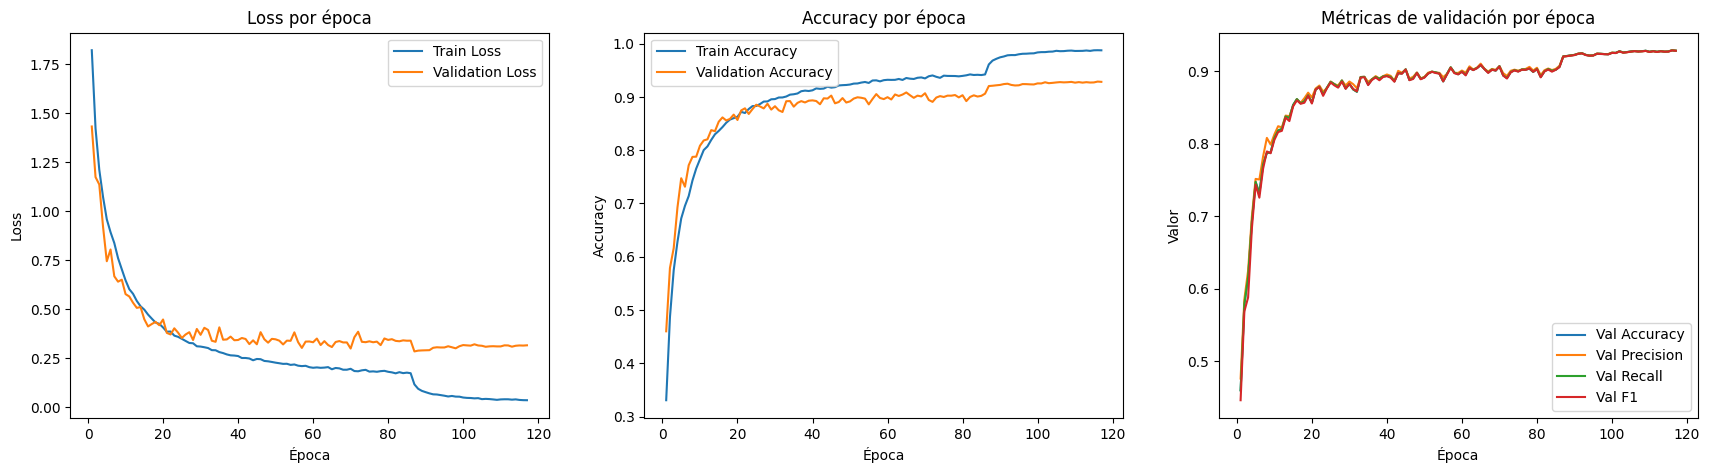

In [ ]:
epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(21,5))

plt.subplot(1,3,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,3,3)
plt.plot(epochs, val_accs, label='Val Accuracy')
plt.plot(epochs, val_precisions, label='Val Precision')
plt.plot(epochs, val_recalls, label='Val Recall')
plt.plot(epochs, val_f1s, label='Val F1')
plt.title('Métricas de validación por época')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.legend()

plt.show()

**Nota:** A continuación guardamos los parámetros y la arquitectura de la red neuronal a fines de llevar a cabo estudios comparativos.

In [ ]:
params_save_path = '/content/gdrive/My Drive/Colab Notebooks/DUIA/2021/Computer Vision/Grupo 9/model22.pth'
if not os.path.exists(params_save_path):
    torch.save(model.state_dict(), params_save_path)
    print(f"Pesos del modelo guardados en: {params_save_path}")
else:
    print(f"No se guardaron los pesos del modelo porque ya existe un archivo de pesos en la ruta {params_save_path}")

Pesos del modelo guardados en: /content/gdrive/My Drive/Colab Notebooks/DUIA/2021/Computer Vision/Grupo 9/model22.pth


In [ ]:
import os

architecture_save_path = '/content/gdrive/My Drive/Colab Notebooks/DUIA/2021/Computer Vision/Grupo 9/Model22.py'

if not os.path.exists(architecture_save_path):
    with open(architecture_save_path, 'w') as f:
        f.write(
"""import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super(ResidualBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.gelu = nn.GELU()
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels:
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels)
        )

  def forward(self, x):
    identity = self.shortcut(x)
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.gelu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out += identity
    out = self.gelu(out)
    return out

class OurCIFAR10Net(nn.Module):
  def __init__(self):
    super(OurCIFAR10Net, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.GELU()
    )
    self.layer2 = nn.Sequential(
        ResidualBlock(64, 128, stride=2),
        ResidualBlock(128, 128)
    )
    self.layer3 = nn.Sequential(
        ResidualBlock(128, 256, stride=2),
        ResidualBlock(256, 256)
    )
    self.layer4 = nn.Sequential(
        ResidualBlock(256, 512, stride=2),
        ResidualBlock(512, 512)
    )
    self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, 256),
        nn.GELU(),
        nn.Dropout(0.4),
        nn.Linear(256, 128),
        nn.GELU(),
        nn.Dropout(0.3),
        nn.Linear(128, 10)
    )
    self.final_activation = nn.Softmax(dim=1)

  def forward(self, x):
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.global_pool(x)
    x = self.classifier(x)
    return x

  def predict(self, x):
    return self.final_activation(self.forward(x))
""")
    print(f"Arquitectura del modelo guardada en: {architecture_save_path}")
else:
    print(f"No se guardó la arquitectura porque ya existe un archivo en: {architecture_save_path}")

Arquitectura del modelo guardada en: /content/gdrive/My Drive/Colab Notebooks/DUIA/2021/Computer Vision/Grupo 9/Model22.py


## 5. Evaluación sobre nuevos datos
En esta última sección preparamos el conjunto `CIFAR 10.1` para la etapa de testing, calculamos métricas por categoría (para ver en qué categorías mejor/peor rinde el modelo) y métricas generales, graficamos la matriz de confusión y, usando un subconjunto de casos acertados y erróneos, mostramos en qué se basó nuestro modelo para hacer las predicciones (con `GradCAM`).

In [ ]:
sys.path.append('/content/gdrive/My Drive/Colab Notebooks/DUIA/2021/Computer Vision/Grupo 9')
from Model22 import OurCIFAR10Net

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using " + str(device) + "\n")
model = OurCIFAR10Net().to(device)
model.load_state_dict(torch.load('/content/gdrive/My Drive/Colab Notebooks/DUIA/2021/Computer Vision/Grupo 9/model22.pth', map_location=device))
model.eval()

images = np.load(path.join(new_datasets_folder, 'cifar10.1_v4_data.npy'))
labels = np.load(path.join(new_datasets_folder, 'cifar10.1_v4_labels.npy'))

images = np.transpose(images, (0, 3, 1, 2))

print(images.shape)
print(labels.shape)

all_preds = []
all_labels = []

with torch.no_grad():
    for img, label in zip(images, labels):
        tensor_img = torch.tensor(img, dtype=torch.float32) / 255.0
        tensor_img = test_transformations(tensor_img)
        tensor_img = tensor_img.unsqueeze(0).to(device)

        outputs = model(tensor_img)
        _, predicted = torch.max(outputs, 1)

        all_preds.append(predicted.item())
        all_labels.append(label)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

"""
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Accuracy:  {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}")"""

Using cuda

(2021, 3, 32, 32)
(2021,)


'\naccuracy = accuracy_score(all_labels, all_preds)\nprecision = precision_score(all_labels, all_preds, average=\'macro\')\nrecall = recall_score(all_labels, all_preds, average=\'macro\')\nf1 = f1_score(all_labels, all_preds, average=\'macro\')\n\nprint(f"Accuracy:  {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}")'

In [ ]:
print("\nMetrics per class:\n")
report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)
metrics_per_class = {label: report[label] for label in classes}
display(pd.DataFrame(data=metrics_per_class).T)
avg_metrics = {avg_metric: report[avg_metric] for avg_metric in ['macro avg', 'weighted avg']}
for key in avg_metrics:
  del avg_metrics[key]['support']
print("\nAverage metrics:\n")
display(pd.DataFrame(data=avg_metrics).T)
print(f"\nOverall accuracy: {report['accuracy']:.3f}\n")


Metrics per class:



,precision,recall,f1-score,support
airplane,0.846535,0.822115,0.834146,208.0
automobile,0.934911,0.745283,0.829396,212.0
bird,0.776256,0.841584,0.807601,202.0
cat,0.743119,0.764151,0.753488,212.0
deer,0.866667,0.892157,0.879227,204.0
dog,0.864583,0.761468,0.809756,218.0
frog,0.872449,0.890625,0.881443,192.0
horse,0.904523,0.857143,0.880196,210.0
ship,0.838323,0.869565,0.853659,161.0
truck,0.755020,0.930693,0.833703,202.0



Average metrics:



,precision,recall,f1-score
macro avg,0.840239,0.837478,0.836262
weighted avg,0.840598,0.835230,0.835242



Overall accuracy: 0.835



Estas métricas dejan ver que el modelo que construimos logró obtener resultados positivos, destacando más en las clases `frog`, `horse` y `deer` (el mejor en sí es frog con **F1-Score de 0.8814**). De todos modos, se puede decir que el modelo no tuvo resultados particularmente malos en ninguna de las clases, siendo `cat` en la que peor rindió con un **F1-Score de 0.7534**.

Algo notorio es que tanto para la precisión, recall como F1-Score, el macro y el weighted average son muy similares entre sí. Esto, al igual que la similitud en sí entre las 3 métricas, se explica por estar muy balanceado el dataset (todas las clases tienen un número de muestras comparable), además de que en general el modelo no tiene fuertes sesgos para predecir una clase en sí.

Los buenos resultados obtenidos en testing son especialmente importantes ya que si bien se habían logrado buenos resultados en el conjunto de validación, este no deja de ser el conjunto a partir del cual se fueron ajustando los hiperparámetros para obtener los mejores resultados posibles en las métricas, por lo que son datos que el modelo "tiene en cuenta indirectamente", a pesar de que no se usen en el training y no se ajusten los pesos en base a ellos. En cambio, los datos de testing solamente fueron evaluados una vez en el mejor de los modelos.

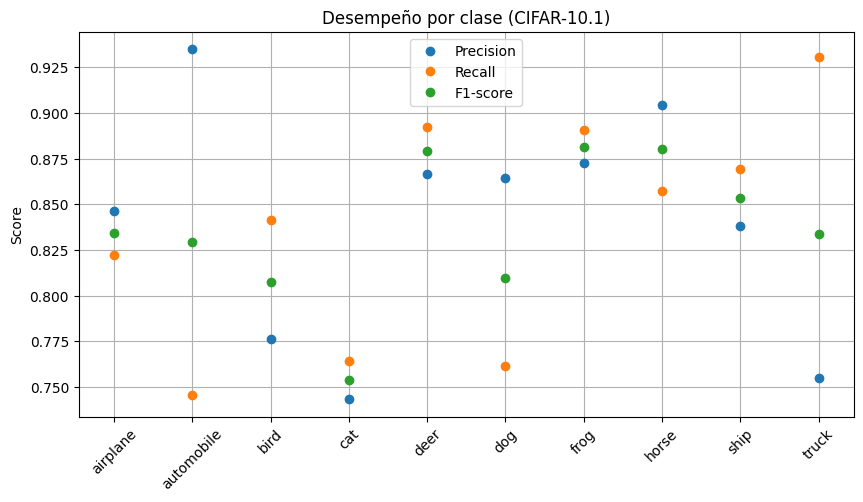

In [ ]:
metrics_per_class = {metric: [report[c][metric] for c in classes] for metric in ["precision", "recall", "f1-score"]}
plt.figure(figsize = (10,5))

for metric, values in metrics_per_class.items():
    plt.plot(classes, values, marker = 'o', linestyle='None', label = metric.capitalize())

plt.title("Desempeño por clase (CIFAR-10.1)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

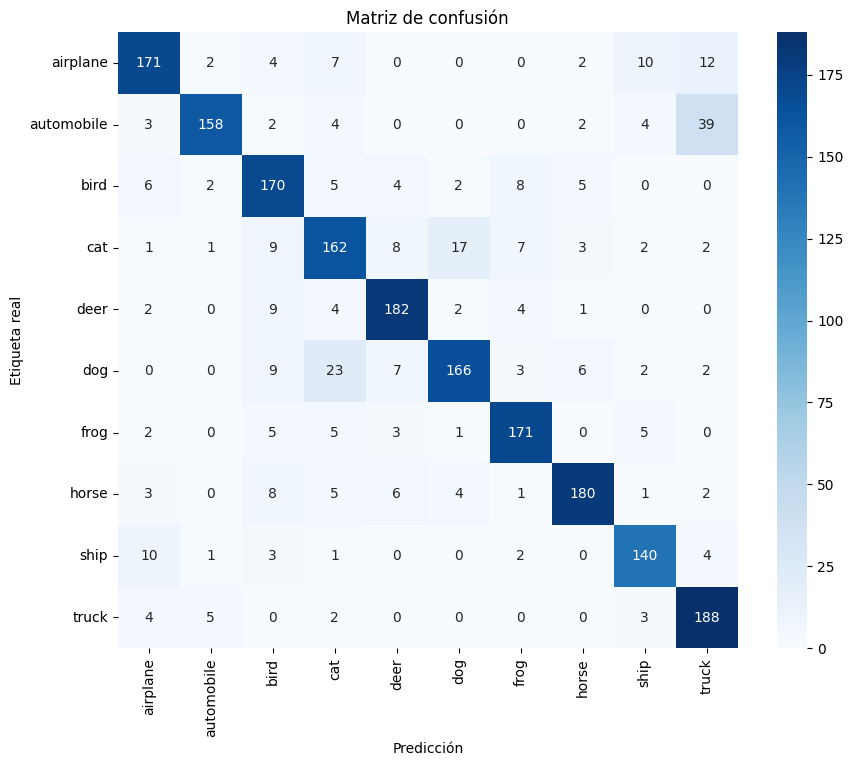

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.show()

Analizando la matriz de confusión, se puede ver que por ejemplo hay algunos casos que le resultan particularmente difíciles de distinguir al modelo. Si bien no se confunde la clase automobile (automóvil) respecto la mayoría de las demás, **en 39 ocasiones que se trataba de un automóvil predijo que era la clase truck (camión)**. Esto se explica naturalmente por la gran similitud que tienen ambos vehículos. Sin embargo, **cuando realmente se trataba de un camión, tan solo se confundió 5 veces prediciendo que era un automóvil**. Por su parte, otro caso en el que se confunde bastante el modelo es **cuando se trata de la clase dog (perro), y predice que es de la clase cat (gato), lo cual sucedió en 23 ocasiones**. También tiene bastante sentido porque los gatos y perros poseen bastantes características en común. Además, a diferencia del ejemplo anterior, **cuando sí se trata de un gato, la cantidad de veces que se confunde prediciendo que es un perro es similar, ya que pasó 17 veces**.

**Si se pone foco en el gráfico de desempeño por clase que está arriba de la matriz de confusión, se puede ver que para las clases automibile, dog y truck las diferencias entre precisión y recall son bastante más grandes que en las demás métricas**. En el caso de automobile y un poco menos notorio en dog, el recall es bastante más bajo que la precisión. Básicamente esto pasa por esa gran cantidad de veces que, como denotaba la matriz de confusión, se confunde una muestra que era automobile prediciendo que era truck, y muchas en las que se confunde una que era dog prediciendo que era cat (y esto afecta directamente al recall porque son casos donde predice muchas veces mal cuando realmente se trataba de esas clases). De manera opuesta, si bien el recall de la clase truck es alto (porque cuando realmente es un camión no suele predecir mal), su precisión es baja, justamente por todas las veces que predice que es un camión pero realmente no lo es (en la mayoría prediciendo automóvil según lo ya explicado).

Más allá de los casos donde se confunde más o menos, se puede observar que la diagonal de la matriz refleja un buen rendimiento general del modelo en las predicciones con el conjunto `CIFAR 10.1`.

In [ ]:
correct_indices = np.where(all_preds == all_labels)[0]
wrong_indices = np.where(all_preds != all_labels)[0]

target_layers = [
    'layer1.0',           # Capa convolucional inicial
    'layer2.1.conv2',     # Segunda convolución del segundo bloque residual de la capa 2
    'layer3.1.conv2',     # Segunda convolución del segundo bloque residual de la capa 3
    'layer4.1.conv2'      # Segunda convolución del segundo bloque residual de la capa 4
]
layer_names = ['Layer1', 'Layer2_0_conv2', 'Layer3_0_conv2', 'Layer4_0_conv2']
cam_extractors = {layer: GradCAM(model, layer) for layer in target_layers}

def imshow_original_img(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0)) / 255.0
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

def get_attributions_for_indices(indices, images, all_preds, n_images=10):
    images_list = []
    attributions_list_list = []

    for idx in indices[:n_images]:
        img_tensor = torch.tensor(images[idx], dtype=torch.float32).unsqueeze(0).to(device) / 255.0
        original_image = np.array(img_tensor.squeeze(0).cpu().numpy().transpose(1,2,0))
        original_image = np.clip(original_image, 0, 1)
        predicted_class = int(all_preds[idx])

        images_list.append(original_image)

        attributions_list = []
        for layer in cam_extractors:
            output = model(img_tensor)
            att = cam_extractors[layer](predicted_class, output)
            attributions_list.append(att)
        attributions_list_list.append(attributions_list)

    return images_list, attributions_list_list

def visualize_images_with_gradcams(images_list, attributions_list_list, classes_list, titles_list, suptitle):
    n_images = len(images_list)
    n_layers = len(titles_list)
    n_rows = n_layers + 2 # Se suma 2 ya que uno es la para imagen original y otro para la fusión de los GradCAMS de todas las capas especificadas

    fig, axes = plt.subplots(n_rows, n_images, figsize=(2 * n_images, 2 * n_rows))
    fig.suptitle(suptitle, fontsize=16)

    if n_rows == 1:
        axes = np.expand_dims(axes, 0)
    if n_images == 1:
        axes = np.expand_dims(axes, 1)

    for col in range(n_images):
        axes[0, col].imshow(images_list[col])
        axes[0, col].set_title(classes_list[col], fontsize=10)
        axes[0, col].axis('off')

        all_att = []

        for row in range(n_layers):
            att = attributions_list_list[col][row]
            att_tensor = att[0] if isinstance(att, list) else att

            all_att.append(att_tensor)

            att_resized = cv2.resize(att_tensor.squeeze().cpu().detach().numpy(),
                                     dsize=(images_list[col].shape[1], images_list[col].shape[0]))
            att_resized = (att_resized - att_resized.min()) / (att_resized.max() + 1e-8)

            overlayed = overlay_mask(to_pil_image(images_list[col]),
                                     to_pil_image(att_resized, mode='F'), alpha=0.5)
            axes[row + 1, col].imshow(overlayed)
            axes[row + 1, col].set_title(titles_list[row], fontsize=8)
            axes[row + 1, col].axis('off')

        # Acá fusionamos los GradCAMS
        fused_cam = GradCAM.fuse_cams(all_att)
        fused_resized = cv2.resize(fused_cam.squeeze().cpu().detach().numpy(),
                                   dsize=(images_list[col].shape[1], images_list[col].shape[0]))
        fused_resized = (fused_resized - fused_resized.min()) / (fused_resized.max() + 1e-8)

        overlayed_fusion = overlay_mask(to_pil_image(images_list[col]),
                                        to_pil_image(fused_resized, mode='F'), alpha=0.5)
        axes[n_layers + 1, col].imshow(overlayed_fusion)
        axes[n_layers + 1, col].set_title("Fusión de detalles de capas", fontsize=8)
        axes[n_layers + 1, col].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

A continuación se muestran 10 ejemplos de predicciones correctas para cada una de las 10 clases, y 10 de predicciones incorrectas cuando la original corresponde a cada una de ellas. Además, en cada caso se presentan los GradCAMS para visualizar en qué detalles hace énfasis cada capa convolucional del modelo durante la inferencia. Para ello, para simplificar, se muestra solo el GradCAM únicamente para las siguientes capas:

- Convolución 2d de capa 1.

- Segunda convolución del segundo bloque residual de la capa 2.

- Segunda convolución del segundo bloque residual de la capa 3.

- Segunda convolución del segundo bloque residual de la capa 4.

Finalmente, se muestra la fusión de los 4 GradCAMS mencionados.

Se puede ver cómo en las primeras capas los detalles son muy finos y a medida que se avanza en capas más profundas, los detalles son cada vez más complejos y grandes.

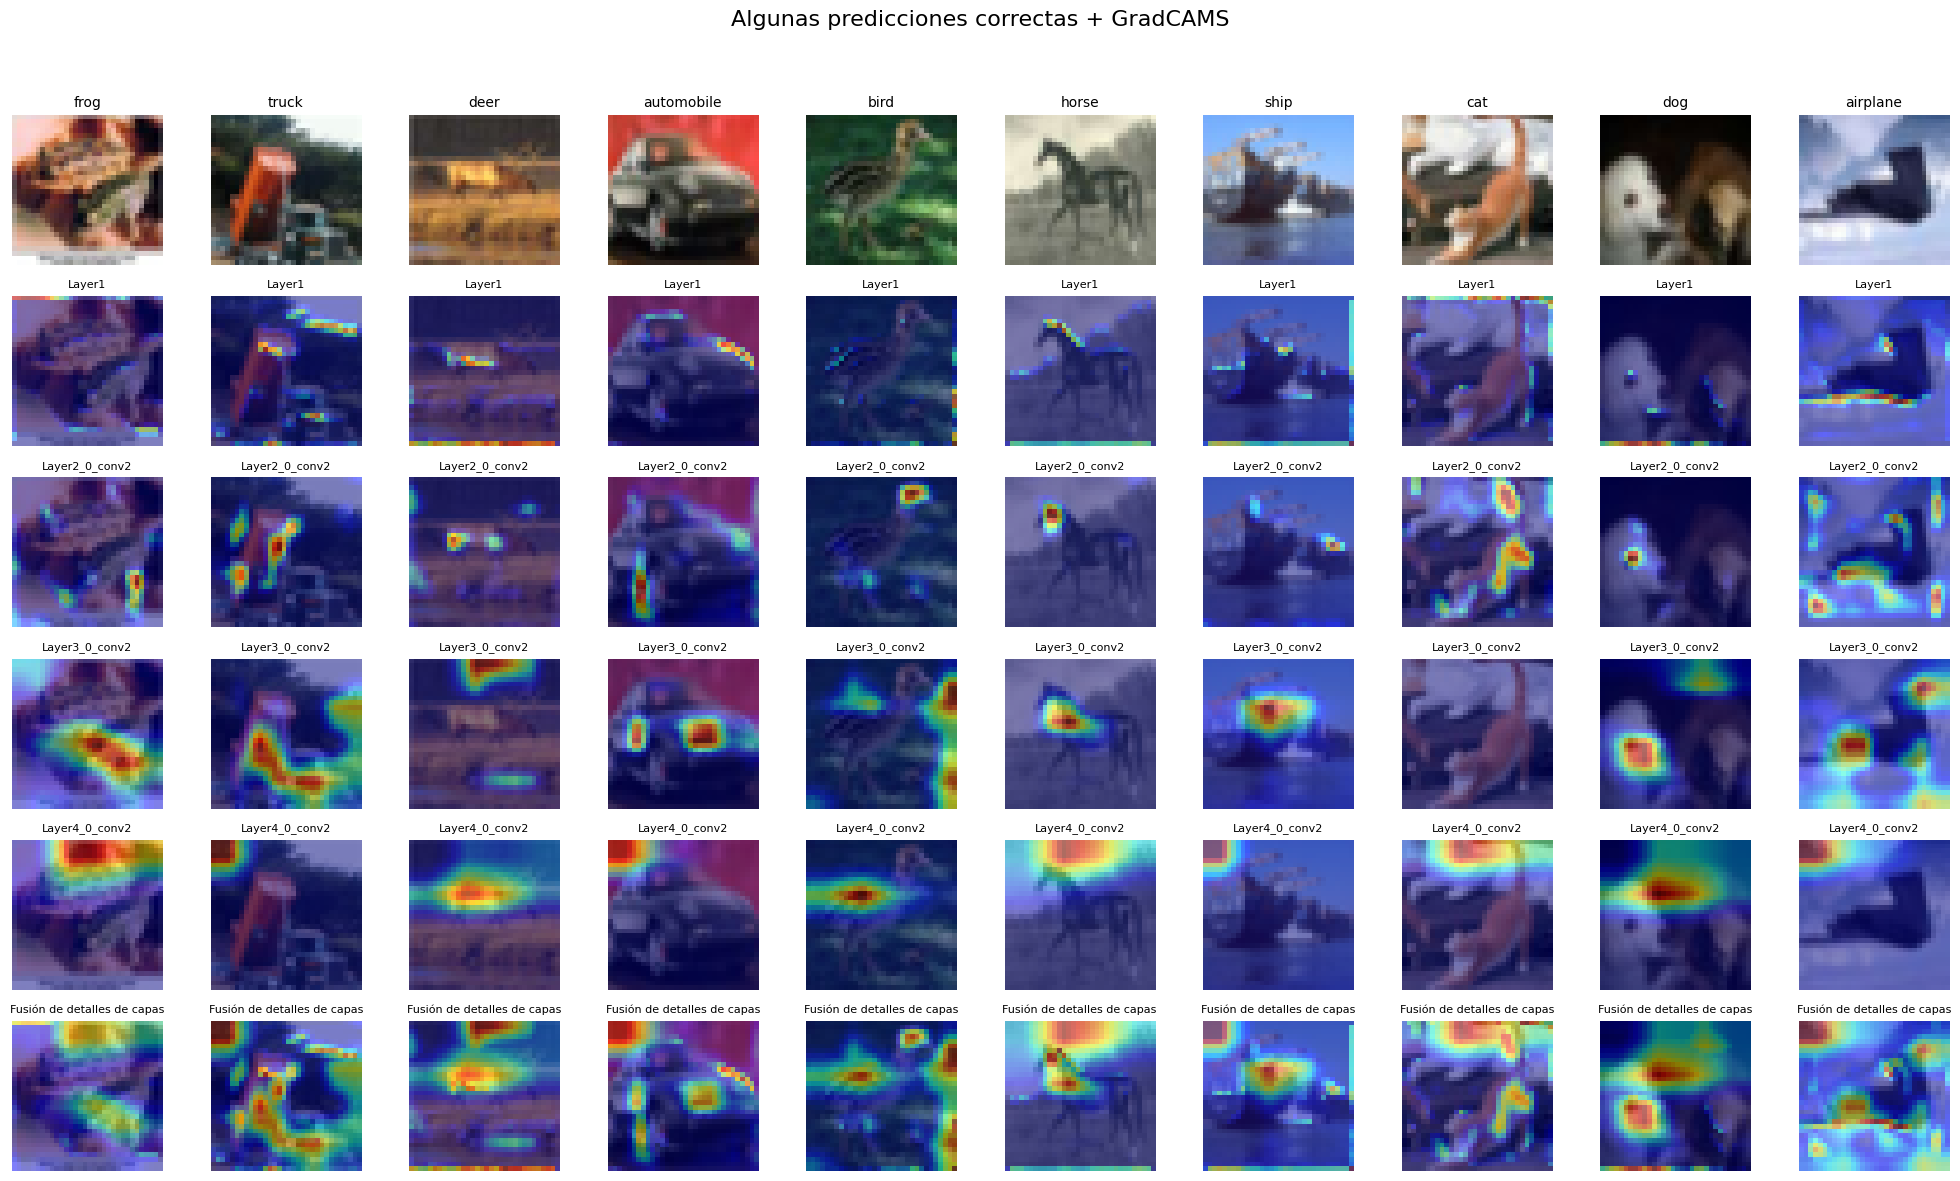

In [ ]:
selected_correct, correct_classes = get_one_per_class(correct_indices, all_labels)
correct_classes = [classes[c] for c in correct_classes]
images_list, attributions_list_list = get_attributions_for_indices(selected_correct, images, all_preds)
visualize_images_with_gradcams(images_list, attributions_list_list, correct_classes, layer_names, "Algunas predicciones correctas + GradCAMS")

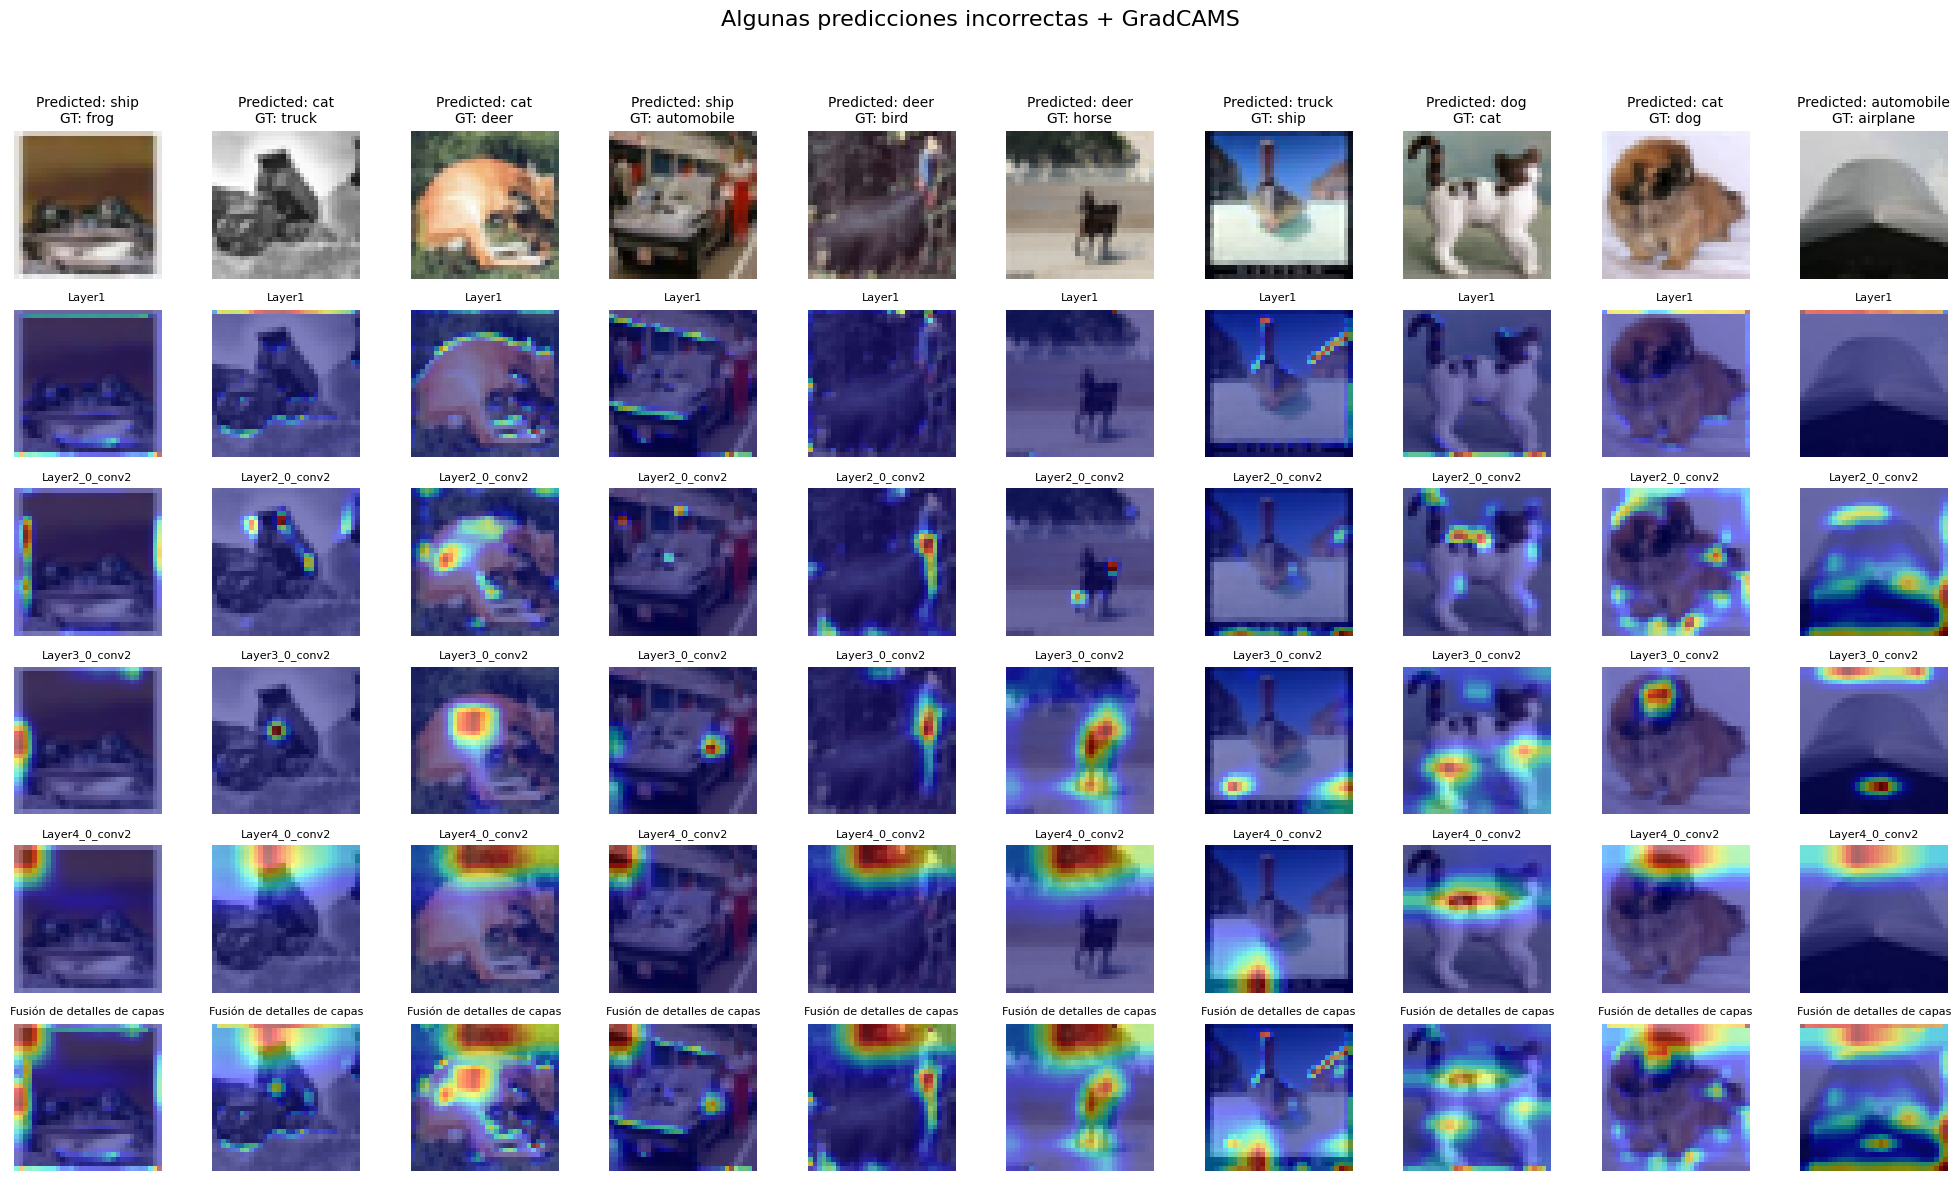

In [ ]:
selected_wrong, wrong_classes = get_one_per_class(wrong_indices, all_labels)
predicts_gts = [f"Predicted: {classes[all_preds[idx]]}\nGT: {classes[wrong_classes[i]]}" for i, idx in enumerate(selected_wrong)]
images_list, attributions_list_list = get_attributions_for_indices(selected_wrong, images, all_preds)
visualize_images_with_gradcams(images_list, attributions_list_list, predicts_gts, layer_names, "Algunas predicciones incorrectas + GradCAMS")